In [41]:
# Beta similarity
from WFlib.utils.statistics import *
import numpy as np
# 17
rng = np.random.default_rng(114514)  # for reproducibility; remove or change seed as desired

# Slope ratio
shadowsocks_vmess_slope_ratio = np.load('/data/exp/lxyu/Dataset/WF/VisualSeg/slope/shadowsocks_vmess_slope_ratio.npz')['slope_ratio']
trojan_vmess_slope_ratio = np.load('/data/exp/lxyu/Dataset/WF/VisualSeg/slope/trojan_vmess_slope_ratio.npz')['slope_ratio']

mean_shadowsocks = []
std_shadowsocks = []
mean_trojan = []
std_trojan = []

shadowsocks_vmess_ratio = np.array(shadowsocks_vmess_slope_ratio.tolist())
trojan_vmess_ratio = np.array(trojan_vmess_slope_ratio.tolist())

for sample_rate in [30, 27, 24, 21, 18, 15]:
    n_sample = int(sample_rate)
    idx = rng.choice(len(shadowsocks_vmess_ratio), n_sample, replace=False)
    sampled = shadowsocks_vmess_ratio[idx]
    mean_shadowsocks.append(np.mean(sampled))
    std_shadowsocks.append(np.std(sampled))

for sample_rate in [30, 27, 24, 21, 18, 15]:
    n_sample = int(sample_rate)
    idx = rng.choice(len(trojan_vmess_ratio), n_sample, replace=False)
    sampled = trojan_vmess_ratio[idx]
    mean_trojan.append(np.mean(sampled))
    std_trojan.append(np.std(sampled))

In [45]:
std_trojan

[0.16597232065976483,
 0.1889785360666138,
 0.1861094240384812,
 0.2268388497264464,
 0.18003875582269113,
 0.2502024074985329]

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def repeated_estimation_errors(x, k_list, n_repeat=10, rng=None, dispersion="std", ddof=0):
    """
    Use the full data as reference, then repeatedly sample k points without replacement.
    
    Returns:
        mean_errors: list of arrays, one array for each k
        disp_errors: list of arrays, one array for each k
        ref: dictionary containing full-data statistics
    """
    if rng is None:
        rng = np.random.default_rng()

    x = np.asarray(x).reshape(-1)
    n = len(x)

    mu_all = np.mean(x)
    std_all = np.std(x, ddof=ddof)
    var_all = np.var(x, ddof=ddof)

    mean_errors = []
    disp_errors = []

    for k in k_list:
        if k > n:
            raise ValueError(f"k={k} is larger than data size n={n}.")

        cur_mean_errors = []
        cur_disp_errors = []

        for _ in range(n_repeat):
            idx = rng.choice(n, size=k, replace=False)
            sampled = x[idx]

            mu_k = np.mean(sampled)
            std_k = np.std(sampled, ddof=ddof)
            var_k = np.var(sampled, ddof=ddof)

            # Mean error normalized by full-data std.
            e_mu = abs(mu_k - mu_all) / mu_all

            if dispersion == "std":
                e_disp = abs(std_k - std_all) / std_all
            elif dispersion == "var":
                if var_all == 0:
                    raise ValueError("Full-data variance is zero; variance error is undefined.")
                e_disp = abs(var_k - var_all) / var_all
            else:
                raise ValueError("dispersion must be either 'std' or 'var'.")

            cur_mean_errors.append(e_mu)
            cur_disp_errors.append(e_disp)

        mean_errors.append(np.asarray(cur_mean_errors))
        disp_errors.append(np.asarray(cur_disp_errors))

    ref = {
        "n": n,
        "mu_all": mu_all,
        "std_all": std_all,
        "var_all": var_all,
    }

    return mean_errors, disp_errors, ref



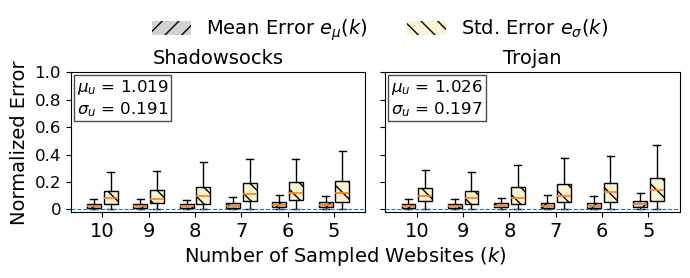

In [41]:
SEED = 114514
N_REPEAT = 200
K_LIST = [30, 27, 24, 21, 18, 15]
DISPERSION = "std"
DDOF = 0

rng = np.random.default_rng(SEED)

shadowsocks_vmess_ratio = np.load(
    "/data/exp/lxyu/Dataset/WF/VisualSeg/slope/shadowsocks_vmess_slope_ratio.npz"
)["slope_ratio"]
# Copy the array 100 times in-place
# shadowsocks_vmess_ratio = np.tile(shadowsocks_vmess_ratio, 100)

trojan_vmess_ratio = np.load(
    "/data/exp/lxyu/Dataset/WF/VisualSeg/slope/trojan_vmess_slope_ratio.npz"
)["slope_ratio"]
# Copy the array 100 times in-place
# trojan_vmess_ratio = np.tile(trojan_vmess_ratio, 100)

shadowsocks_vmess_ratio = np.asarray(shadowsocks_vmess_ratio).reshape(-1)
trojan_vmess_ratio = np.asarray(trojan_vmess_ratio).reshape(-1)

ss_mean_err, ss_disp_err, ss_ref = repeated_estimation_errors(
    shadowsocks_vmess_ratio,
    K_LIST,
    n_repeat=N_REPEAT,
    rng=rng,
    dispersion=DISPERSION,
    ddof=DDOF,
)

ss_mu, ss_std = ss_ref["mu_all"], ss_ref["std_all"]

tr_mean_err, tr_disp_err, tr_ref = repeated_estimation_errors(
    trojan_vmess_ratio,
    K_LIST,
    n_repeat=N_REPEAT,
    rng=rng,
    dispersion=DISPERSION,
    ddof=DDOF,
)

tr_mu, tr_std = tr_ref["mu_all"], tr_ref["std_all"]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)

def plot_grouped_boxplot(ax, mean_errors, disp_errors, k_list, title, dispersion="std", ylabel=None, show_legend=False, set_xlabel=False):
    base_pos = np.arange(len(k_list))
    offset = 0.18
    width = 0.30

    mean_pos = base_pos - offset
    disp_pos = base_pos + offset

    bp_mean = ax.boxplot(
        mean_errors,
        positions=mean_pos,
        widths=width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )

    bp_disp = ax.boxplot(
        disp_errors,
        positions=disp_pos,
        widths=width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )

    # 使用灰度 + hatch，适合论文黑白打印
    for box in bp_mean["boxes"]:
        box.set_facecolor("lightgray")
        box.set_hatch("//")

    for box in bp_disp["boxes"]:
        box.set_facecolor("#fbf3d5")
        box.set_hatch("\\\\")

    ax.axhline(0, linestyle="--", linewidth=0.8)

    ax.set_title(title, fontsize=14)
    ax.set_xticks(base_pos)
    ax.set_xticklabels([10, 9, 8, 7, 6, 5], fontsize=14)
    # Do not set xlabel in this function, instead do it after subplots
    if set_xlabel:
        ax.set_xlabel("Number of Websites", fontsize=14)
    ax.set_ylim(top=1)
    ax.set_yticks([0, .2, .4, .6, .8, 1.0])
    ax.set_yticklabels([0, .2, .4, .6, .8, 1.0], fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=14)

    disp_label = r"$e_{\sigma}(k)$" if dispersion == "std" else r"$e_{\sigma^2}$"

    legend_handles = [
        Patch(facecolor="lightgray", hatch="//", label=r"$e_{\mu}(k)$"),
        Patch(facecolor="#fbf3d5", hatch="\\\\", label=disp_label),
    ]
    if show_legend:
        # Only create the legend for the provided axis
        ax.legend(handles=legend_handles, frameon=False, fontsize=14)
    return legend_handles

# Disable x-label in both subplots, add it as shared x-label to fig after
legend_handles = plot_grouped_boxplot(
    axes[0],
    ss_mean_err,
    ss_disp_err,
    K_LIST,
    "Shadowsocks",
    dispersion=DISPERSION,
    ylabel="Normalized Error",
    show_legend=False,
    set_xlabel=False
)

plot_grouped_boxplot(
    axes[1],
    tr_mean_err,
    tr_disp_err,
    K_LIST,
    "Trojan",
    dispersion=DISPERSION,
    ylabel=None,
    show_legend=False,
    set_xlabel=False
)

# Set a shared x-label for both subplots
fig.supxlabel(r"Number of Sampled Websites $(k)$", fontsize=14, x=0.5, y=0.1)

# Annotate Shadowsocks mean/std to upper left of first subplot
axes[0].text(
    0.02, 0.96, 
    r"$\mu_u$ = {:.3f}".format(ss_mu) + "\n" + r"$\sigma_u$ = {:.3f}".format(ss_std),
    transform=axes[0].transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(facecolor='white', alpha=0.7, pad=2.0)
)

# Annotate Trojan mean/std to upper left of second subplot
axes[1].text(
    0.02, 0.96, 
    r"$\mu_u$ = {:.3f}".format(tr_mu) + "\n" + r"$\sigma_u$ = {:.3f}".format(tr_std),
    transform=axes[1].transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(facecolor='white', alpha=0.7, pad=2.0)
)

# Place the shared legend above the subplots
disp_label = r"Std. Error $e_{\sigma}(k)$" if DISPERSION == "std" else r"$e_{\sigma^2}$"
shared_legend_handles = [
    Patch(facecolor="lightgray", hatch="//", label=r"Mean Error $e_{\mu}(k)$"),
    Patch(facecolor="#fbf3d5", hatch="\\\\", label=disp_label),
]
fig.legend(
    handles=shared_legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.55, 1.13),
    ncol=2,
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.savefig("gaussian_param_estimation.pdf", bbox_inches="tight")
plt.show()

In [2]:
mean_shadowsocks, std_shadowsocks

([1.1732275929335536,
  1.0785775346119246,
  1.0192279720137198,
  1.1117500854157898,
  1.1097092338916459,
  1.0880603086429672,
  1.0904386904065324],
 [0.15197888049031782,
  0.0497479000453179,
  0.09396512084301416,
  0.13399115672165327,
  0.0861221276310762,
  0.11024744615630379,
  0.10897090516533754])

In [3]:
mean_trojan, std_trojan

([1.0670735622802188,
  0.9901081182361563,
  1.0831850592470336,
  1.0548212956927978,
  1.1277953125841256,
  1.127394761190335,
  1.0586708771827353],
 [0.1292690297224835,
  0.07129645195908056,
  0.08877791135215027,
  0.12518831281780254,
  0.13226667112312943,
  0.14147918891662786,
  0.12121124783264817])

In [3]:
import numpy as np
from WFlib.tools.extractor import sni_cover
import pandas as pd
from WFlib.tools.extractor import SNI_BIN_SIZE
from WFlib.utils.statistics import *

def bound_gen(*ranges: tuple):
    lower_bounds = np.array([r[0] for r in ranges])
    upper_bounds = np.array([r[1] for r in ranges])
    return lower_bounds, upper_bounds

def proportion_in_range(arr, lower_bounds, upper_bounds):
    """
    Calculate the proportion of the array that is in the range of the lower and upper bounds.
    """
    assert len(lower_bounds) == len(upper_bounds)
    in_idx = set()
    for (lower, upper) in zip(lower_bounds, upper_bounds):
        assert lower <= upper
        in_idx.update(np.where(np.logical_and(arr > lower, arr < upper))[0])
    return len(in_idx) / len(arr)

def get_utility(filtered, remained, mu):
    return (1 + mu) * filtered * remained / (mu * filtered + remained)

In [34]:
INTRINSIC_SNIS = ['firefox-settings-attachments.cdn.mozilla.net', 'firefox.settings.services.mozilla.com', 'content-signature-2.cdn.mozilla.net']
STAT_ROOT = "../data_extract"
PROTOCOLS = ["vmess", "trojan", "shadowsocks"]
COVERAGE_RANGE = list(range(11))

optimal_coverage = {"vmess": [], "trojan": [], "shadowsocks": []}
optimal_utility = {"vmess": [], "trojan": [], "shadowsocks": []}

ratios = [0.05, 0.10, 0.15, 0.20]
# 2023 43 

rng = np.random.default_rng(3)  # Use default random generator for reproducibility

for protocol in PROTOCOLS:
    df_attach = pd.read_csv(f"{STAT_ROOT}/firefox-settings-attachments.cdn.mozilla.net.csv")
    attachments_flow = df_attach[protocol].dropna().to_numpy().astype(np.int64)
    df_services = pd.read_csv(f"{STAT_ROOT}/firefox.settings.services.mozilla.com.csv")
    services_flow = df_services[protocol].dropna().to_numpy().astype(np.int64)
    df_sign = pd.read_csv(f"{STAT_ROOT}/content-signature-2.cdn.mozilla.net.csv")
    signature_flow = df_sign[protocol].dropna().to_numpy().astype(np.int64)
    website_flow = np.load(f"/data/exp/lxyu/Dataset/WF/VisualSeg/flow_size/{protocol}.npz")['flow_size']

    for ratio in ratios:
        website_flow_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
        website_flow_small_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
        BIH_flow_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
        BIH_flow_large_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
        BIH_flow_middle_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
        BIH_flow_small_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
        utility = {"vmess": [], "trojan": [], "shadowsocks": []}

        website_flow_small = website_flow[website_flow < 30_000]

        # Concatenate the flows of the three SNIs.
        BIH_flow = np.concatenate([attachments_flow, services_flow, signature_flow])
        BIH_flow_large = attachments_flow[(attachments_flow > 2_000_000) & (attachments_flow <= 3_000_000)]
        BIH_flow_middle = signature_flow[(signature_flow > 80_000) & (signature_flow <= 120_000)]
        BIH_flow_small = services_flow[services_flow <= 30_000]
        for coverage in COVERAGE_RANGE:
            # Given coverage, we first calculate the total cover of the intrinsic SNIs.
            total_cover = []
            for sni in INTRINSIC_SNIS:
                df = pd.read_csv(f"{STAT_ROOT}/{sni}.csv")
                array = df[protocol].dropna().to_numpy().astype(np.int64)
                array = rng.choice(array, size=int(len(array) * ratio), replace=False) if len(array) > 0 else array
                cover, actual_coverage = greedy_mass_covering(array, SNI_BIN_SIZE[sni], float(coverage)/10)
                total_cover += cover
            lower_bounds, upper_bounds = bound_gen(*total_cover)

            website_flow_remaining[protocol].append(1 - proportion_in_range(website_flow, lower_bounds, upper_bounds))
            website_flow_small_remaining[protocol].append(1 - proportion_in_range(website_flow_small, lower_bounds, upper_bounds))
            BIH_flow_filtered[protocol].append(proportion_in_range(BIH_flow, lower_bounds, upper_bounds))
            BIH_flow_large_filtered[protocol].append(proportion_in_range(BIH_flow_large, lower_bounds, upper_bounds))
            BIH_flow_middle_filtered[protocol].append(proportion_in_range(BIH_flow_middle, lower_bounds, upper_bounds))
            BIH_flow_small_filtered[protocol].append(proportion_in_range(BIH_flow_small, lower_bounds, upper_bounds))
            utility[protocol].append(get_utility(BIH_flow_large_filtered[protocol][-1], website_flow_small_remaining[protocol][-1], 5))

        max_util = np.max(utility[protocol])
        optimal_idx = np.where(utility[protocol] == max_util)[0][0]  # the first max
        optimal_coverage[protocol].append(COVERAGE_RANGE[optimal_idx])
        optimal_utility[protocol].append(max_util)

In [35]:
optimal_coverage

{'vmess': [5, 5, 5, 5], 'trojan': [4, 4, 4, 4], 'shadowsocks': [5, 5, 5, 5]}

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (4).

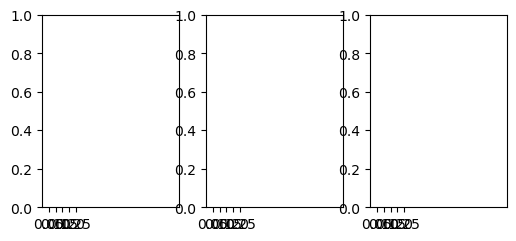

In [21]:
import matplotlib.pyplot as plt
import numpy as np

protocols = ["vmess", "shadowsocks", "trojan"]

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5), sharex=True)

colors = {"Coverage": "tab:blue", "Utility": "tab:orange"}
protocol_labels = {"vmess": "VMess", "shadowsocks": "Shadowsocks", "trojan": "Trojan"}

# Left axis: Utility; right axis: Coverage
left_yticks = np.arange(0.6, 1.01, 0.1)
right_yticks = np.arange(0, 1.01, 0.2)

lines = []
labels = []
ratio_labels = ["5%", "10%", "15%", "20%"]
twin_axes = []

for i, protocol in enumerate(protocols):
    ax = axes[i]
    cov = np.array(optimal_coverage[protocol]) / 10
    util = np.array(optimal_utility[protocol])
    x = ratios
    ax.set_xticks(x)
    ax.set_xticklabels(ratio_labels, fontsize=12, rotation=30)

    ax2 = ax.twinx()
    twin_axes.append(ax2)

    # Utility on left, Coverage on right
    l1, = ax2.plot(x, cov, marker='o', linestyle="--", color=colors["Coverage"], label=r"Optimal Coverage $\alpha^*$")
    l2, = ax.plot(x, util, marker='s', color=colors["Utility"], label="Utility")
    

    ax.set_title(protocol_labels[protocol])
    ax.set_yticks(left_yticks)
    ax2.set_yticks(right_yticks)

    if i == 0:
        ax.set_ylabel("Utility", fontsize=14)
        lines.extend([l1, l2])
        labels.extend([r"Optimal Coverage $\alpha^*$", "Utility"])
    if i == 2:
        ax2.set_ylabel("Coverage", fontsize=14)

    ax.tick_params(axis="y", labelleft=(i == 0))
    ax2.tick_params(axis="y", labelright=(i == 2))

    if i == 1:
        ax.set_xlabel("Sampling Ratio", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.93])
# Re-apply after tight_layout so only edge subplots keep tick labels
for i, (ax, ax2) in enumerate(zip(axes, twin_axes)):
    ax.tick_params(axis="y", labelleft=(i == 0))
    ax2.tick_params(axis="y", labelright=(i == 2))
fig.legend(lines, labels, loc='upper center', ncol=2, fontsize='large', bbox_to_anchor=(0.5, 1.06))
fig.savefig("coverage_stability.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [14]:
%load_ext autoreload
%autoreload 2

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from WFlib.tools.extractor import *

# Use n-gram method to identify proxy protocols
root_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract"
array_dir = f"{root_dir}/arrays"
db_file = f"{root_dir}/database.csv"
db = pd.read_csv(db_file)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
STRIP_INDICES = {"vmess": [3, 4], "shadowsocks": [4, 5], "trojan": [3, 4]}
PROTOCOLS = ["vmess", "shadowsocks", "trojan"]
PROTOCOLS_DISPLAY = {"vmess": "VMess", "shadowsocks": "Shadowsocks", "trojan": "Trojan"}
PROTOCOL_LABEL = {"vmess": 0, "shadowsocks": 1, "trojan": 2}
LABEL_TO_PROTOCOL = {v: k for k, v in PROTOCOL_LABEL.items()}
NGRAM_DB = {}
BINNERS = {}
OPTIMAL_VOCAB_SIZE = {"vmess": 90, "shadowsocks": 7, "trojan": 30}
TRAIN_SAMPLES = {'vmess': 4000, 'shadowsocks': 4000, 'trojan': 4000}

# Train one n-gram DB and binner per protocol
for protocol in PROTOCOLS:
    with open(f"{protocol}.pkl", "rb") as f:
        flows = pickle.load(f)
    BINNERS[protocol] = PacketSizeBinner.fit_uniform(
        LOWER_BOUND, UPPER_BOUND, vocabulary_size=OPTIMAL_VOCAB_SIZE[protocol]
    )
    NGRAM_DB[protocol] = train_ngram_db(
        flows[:TRAIN_SAMPLES[protocol]], STRIP_INDICES[protocol], WINDOW_SIZE, BINNERS[protocol]
    )

n_unknowns = []
n_corrects = []
n_wrongs = []
f1_scores = []
cm_list = []

for frac in [1.0]:
    SAMPLE_FRAC = frac
    SAMPLE_PER_PROTOCOL = None
    RANDOM_SEED = 42

    eval_db = db[db["protocol"].isin(PROTOCOL_LABEL)]
    pcap_keys = eval_db[["protocol", "host", "id"]].drop_duplicates()
    if SAMPLE_FRAC is not None:
        pcap_keys = pd.concat(
            [
                g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
                for _, g in pcap_keys.groupby("protocol")
            ],
            ignore_index=True,
        )
    if SAMPLE_PER_PROTOCOL is not None:
        pcap_keys = (
            pcap_keys.groupby("protocol", group_keys=False)
            .head(SAMPLE_PER_PROTOCOL)
            .reset_index(drop=True)
        )
    eval_db = eval_db.merge(pcap_keys, on=["protocol", "host", "id"], how="inner")

    # One sample per (protocol, host, id); ground truth is the group protocol
    y_true = []
    y_pred = []
    n_all_zero = 0
    n_ties = 0

    for (true_p, host, pcap_id), group in eval_db.groupby(["protocol", "host", "id"]):
        if true_p not in PROTOCOL_LABEL:
            continue
        paths = group.apply(
            lambda row: f"{array_dir}/{array_path(row['host'], row['id'], row['transport'], row['stream'], row['protocol'])}",
            axis=1,
        )
        vote = pcap_protocol_votes(
            paths,
            NGRAM_DB,
            BINNERS,
            PROTOCOLS,
            WINDOW_SIZE,
            strip_indices=STRIP_INDICES,
            min_len=15,
        )
        top = max(vote.values())
        if top == 0:
            # Heuristic classifier 
            vote = pcap_protocol_votes_heuristic(
                paths,
                NGRAM_DB,
                BINNERS,
                PROTOCOLS,
                WINDOW_SIZE,
            )
            top = max(vote.values())
            if top == 0:
                pred_p = "unknown"
                n_all_zero += 1
            else:
                pred_p = predict_protocol_from_votes(vote)
        else:
            pred_p = predict_protocol_from_votes(vote)
        if top != 0 and sum(v == top for v in vote.values()) > 1:
            n_ties += 1
            continue
        
        y_true.append(PROTOCOL_LABEL[true_p])
        y_pred.append(PROTOCOL_LABEL[pred_p])

    macro_p = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_r = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=list(PROTOCOL_LABEL.values()))
    cm_list.append(cm)
    # Count metrics as requested
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    # Unknown = 3; correct = y_pred == y_true (but not Unknown); wrong = not Unknown and wrong label
    n_unknown = np.sum(y_pred_arr == 3)
    n_correct = np.sum((y_pred_arr != 3) & (y_pred_arr == y_true_arr))
    n_wrong = np.sum((y_pred_arr != 3) & (y_pred_arr != y_true_arr))
    n_unknowns.append(n_unknown)
    n_corrects.append(n_correct)
    n_wrongs.append(n_wrong)
    f1_scores.append(macro_f1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
f1_scores

[0.9997903943647471,
 0.9998094435369923,
 0.9998729693746714,
 0.9998094435369923]

In [13]:
cm_list

[array([[18207,     0,     1],
        [    0, 16912,     0],
        [   10,     0, 16823]]),
 array([[14566,     0,     0],
        [    0, 13530,     0],
        [    8,     0, 13458]]),
 array([[10925,     0,     0],
        [    0, 10147,     0],
        [    4,     0, 10096]]),
 array([[7283,    0,    0],
        [   0, 6765,    0],
        [   4,    0, 6729]])]

In [4]:
%load_ext autoreload
%autoreload 2

# VMess: train :400 test :20000-24000 [3, 4]
# Shadowsocks: train :40 test :20000-24000 [4, 5]
# Trojan: train :40 test :20000-24000 [3, 4]
import pickle

from WFlib.tools.extractor import *
import matplotlib.pyplot as plt

def fit_uniform_binner(v):
    return PacketSizeBinner.fit_uniform(LOWER_BOUND, UPPER_BOUND, v)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
PROTOCOLS = ['vmess', 'shadowsocks', 'trojan']
PROTOCOLS_DISPLAY = {'vmess': 'VMess', 'shadowsocks': 'Shadowsocks', 'trojan': 'Trojan'}

STRIP_INDICES = {'vmess': [3, 4], 'shadowsocks': [4, 5], 'trojan': [3, 4]}
TRAIN_SAMPLES = {'vmess': 400, 'shadowsocks': 40, 'trojan': 4}
LAMBDA_PENALTY = {'vmess': 0.001, 'shadowsocks': 0.01, 'trojan': 0.002}
TEST_START = 4000
VOCABULARY_RANGE = [1, 2, 4, 7, 9, 11, 30, 50, 70, 90, 101, 300, 500, 700, 900, 1001, 1400, 1800, 2000, 2400, 2800]
TEST_FRACS = [0.03, 0.025, 0.02, 0.015, 0.01]

rng = np.random.default_rng(42)

optimal_vocab = {protocol: [] for protocol in PROTOCOLS}
optimal_f1 = {protocol: [] for protocol in PROTOCOLS}

flow_cache = {}
for protocol in PROTOCOLS:
    with open(f'{protocol}.pkl', 'rb') as f:
        flow_cache[protocol] = pickle.load(f)

for protocol in PROTOCOLS:
    flows = flow_cache[protocol]
    flows_train = flows[:TRAIN_SAMPLES[protocol]]
    test_pool = flows[TEST_START:]

    for frac in TEST_FRACS:
        n_test = max(1, int(len(test_pool) * frac))
        if frac >= 1.0:
            flows_test = test_pool
        else:
            idx = rng.choice(len(test_pool), n_test, replace=False)
            flows_test = [test_pool[i] for i in idx]

        best_f1 = -1.0
        for vocabulary_size in VOCABULARY_RANGE:
            binner = PacketSizeBinner.fit_uniform(
                LOWER_BOUND, UPPER_BOUND, vocabulary_size=vocabulary_size
            )
            ngram_db = train_ngram_db(
                flows_train, STRIP_INDICES[protocol], WINDOW_SIZE, binner
            )
            p, r = evaluate_ngram(
                flows_test, STRIP_INDICES[protocol], WINDOW_SIZE, ngram_db, binner
            )
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            if f1 > best_f1:
                best_f1 = f1

        rows = sweep_vocabulary_objective(
            flows_test,
            STRIP_INDICES[protocol],
            WINDOW_SIZE,
            VOCABULARY_RANGE,
            fit_binner=fit_uniform_binner,
            lambda_penalty=LAMBDA_PENALTY[protocol],
        )
        df_obj = pd.DataFrame(rows)

        optimal_f1[protocol].append(best_f1)
        optimal_vocab[protocol].append(int(df_obj.loc[df_obj["objective"].idxmax(), "vocabulary_size"]))
        print(
            f"{protocol} test_frac={frac:.2f} "
            f"n_test={len(flows_test)} best_f1={best_f1:.4f} vocab*={optimal_vocab[protocol]}"
        )

vmess test_frac=0.03 n_test=13140 best_f1=0.9734 vocab*=[90]
vmess test_frac=0.03 n_test=10950 best_f1=0.9755 vocab*=[90, 90]
vmess test_frac=0.02 n_test=8760 best_f1=0.9749 vocab*=[90, 90, 90]
vmess test_frac=0.01 n_test=6570 best_f1=0.9749 vocab*=[90, 90, 90, 90]
vmess test_frac=0.01 n_test=4380 best_f1=0.9755 vocab*=[90, 90, 90, 90, 90]
shadowsocks test_frac=0.03 n_test=11528 best_f1=0.9770 vocab*=[7]
shadowsocks test_frac=0.03 n_test=9607 best_f1=0.9785 vocab*=[7, 7]
shadowsocks test_frac=0.02 n_test=7685 best_f1=0.9783 vocab*=[7, 7, 7]
shadowsocks test_frac=0.01 n_test=5764 best_f1=0.9795 vocab*=[7, 7, 7, 7]
shadowsocks test_frac=0.01 n_test=3842 best_f1=0.9771 vocab*=[7, 7, 7, 7, 7]
trojan test_frac=0.03 n_test=12130 best_f1=0.9808 vocab*=[30]
trojan test_frac=0.03 n_test=10108 best_f1=0.9829 vocab*=[30, 30]
trojan test_frac=0.02 n_test=8086 best_f1=0.9821 vocab*=[30, 30, 30]
trojan test_frac=0.01 n_test=6065 best_f1=0.9800 vocab*=[30, 30, 30, 30]
trojan test_frac=0.01 n_test=404